In [ ]:
# @title
!pip install mysql-connector-python

# Immigrazione: dati alla mano
## Analisi generale sull'immigrazione in Italia

Negli ultimi anni, tra gli argomenti al centro dell'attenzione pubblica del nostro Paese, abbiamo l'immigrazione. Un tema che polarizza fortemente il dibattito politico, e questo nella maggior parte dei casi è dovuto ad una grande disinformazione a riguardo.
La nostra analisi nasce dalla volontà di affrontare proprio la disinformazione che aleggia sull'argomento. In questo caso più che mai è importante ricordare che dietro i dati che stiamo analizzando ci sono persone vere e storie di sofferenza: eventuali pregiudizi si ripercuoterebbero direttamente sulle vite di queste persone. Per questo motivo vogliamo lasciare che siano i dati a parlare, per cercare di mantenere l'analisi il più imparziale possibile ed evitare che eventuali pregiudizi possano falsare la narrazione a favore di un'opinione piuttosto che di un'altra.

Nello specifico, la nostra analisi si concentra su tre aspetti principali:

*   studio generale dei flussi migratori in Italia

*   quantificare l'impatto economico dell'immigrazione in Italia in modo da capire se sia o meno una risorsa
*   identificare una possibile correlazione tra emarginazione e tasso di criminalità





# Fase di raccolta dati

Dopo aver stabilito lo scopo dell'analisi e aver individuato una prima base dati utile, ci siamo dedicati alla ricerca di fonti verificate e verificabili che potessero fornirci i dati che cercavamo.
Ci siamo concentrati su siti autorevoli come quello del Ministero dell'Interno e dell'OSCAD (Osservatorio per la sicurezza contro gli atti discriminatori), il sito INPS per i dati salariali e previdenziali, mentre sui siti di ISTAT ed il corrispettivo europeo EUROSTAT abbiamo trovato i dati più generali relativi alla popolazione straniera.
Tuttavia, nonostante la premessa iniziale di voler voler mantenere l'analisi imparziale ci siamo resi conto che, data la complessità dell'argomento, trovare sufficienti dati a supporto di ogni punto di vista dell'analisi non è stato possibile.
Per questo motivo abbiamo preferito limitare inizialmente la portata dell'analisi: abbiamo potuto lavorare soltanto su poche regioni e pochi paesi dal momento che non tutti gli indicatori che abbiamo preso in considerazione sono disponibili per tutte le zone geografiche interessate.

## Fonti utilizzate
*   [ISTAT - Popolazione straniera residente per regione e sesso](https://esploradati.istat.it/databrowser/#/it/dw/categories/IT1,POP,1.0/POP_FOREIGNIM/DCIS_POPSTRRES1/IT1,29_7_DF_DCIS_POPSTRRES1_1,1.0)
*   [INPS - Osservatorio sugli stranieri](https://servizi2.inps.it/servizi/osservatoristatistici/1059)
*   [Eurostat - Asylum and managed migration](https://ec.europa.eu/eurostat/databrowser/view/migr_imm11prv/default/table?lang=en&category=migr.migr_cit.migr_immi)
*   [Ministero dell'Interno & OSCAD](https://www.interno.gov.it/it/stampa-e-comunicazione/dati-e-statistiche/dati-sulle-segnalazioni-oscad)
*   [ISTAT - Crimini denunciati per regione](https://esploradati.istat.it/databrowser/#/it/dw/categories/IT1,Z0840JUS,1.0/JUS_CRIMINAL/DCCV_IMPUTATI_A)







# Fase di creazione della base dati

Una volta recuperati una quantità di dati sufficiente per mettere in piedi una prima analisi, ci siamo dedicati alla costruzione del database. Tramite MySQL Workbench abbiamo strutturato i dati in due dataset separati: uno per inserire i dati relativi ai flussi migratori e l'altro per i dati riguardanti il nostro studio sulla discriminazione mediante dati economici.
Qui di seguito abbiamo riportiamo i due diagrammi strutturali dei nostri database. Senza entrare nel dettaglio, i diagrammi strutturali mostrano come vengono collegate le varie tabelle ottenute dalle fonti sopracitate, permettendo ai dati di comunicare tra loro. Nella fase successiva spiegheremo anche i vari indici utilizzati e le loro correlazioni.

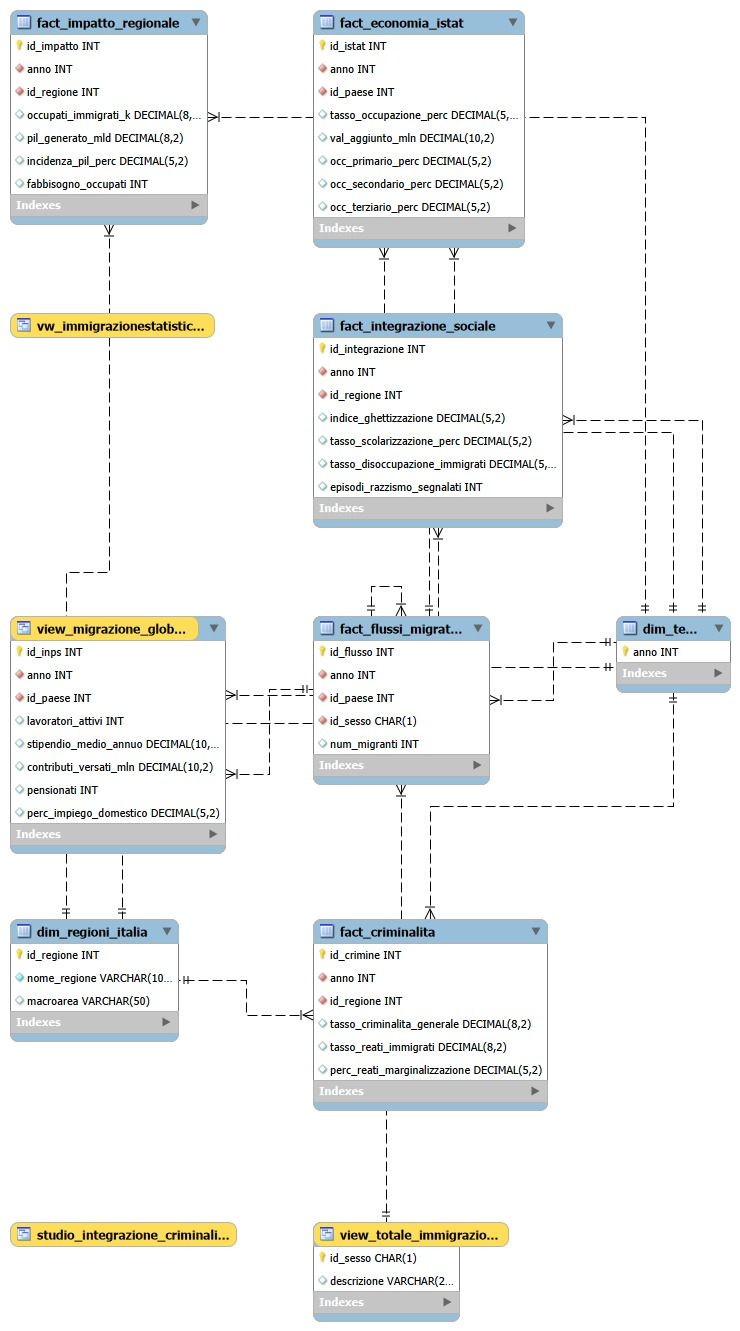

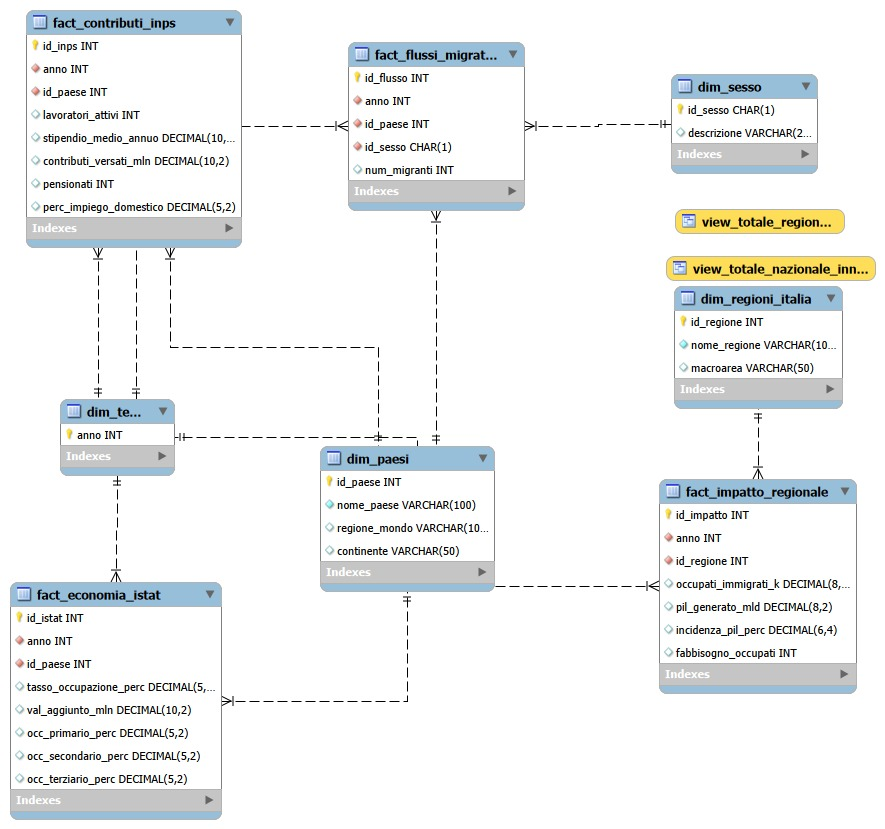

# Fase di analisi dei dati esplorativa

Una volta costruita la nostra base dati, ci siamo spostati su Google Colab per la fase di analisi esplortiva dei dati che consiste nell'interrogare i database integrando i linguaggi di programmazione SQL e Python.
Come prima cosa, abbiamo stabilito una connessione tra il nostro server MySQL e Google Colab, in modo da poter interrogare i dataset tramite query SQL richiamate con linguaggio Python.


In [ ]:
USER = 'root'
PASSWORD = '25DATITA034!'
HOST = '5.tcp.eu.ngrok.io'
PORT = 14158
DATABASE = 'immigrazione_3nf'

In [ ]:
import mysql.connector
import pandas as pd

In [ ]:
#procedura per stabilire una connessione con SQL
def stabilisciConnessione():
  conn = mysql.connector.connect(
  user=USER,
  password=PASSWORD,
  host=HOST,
  port=PORT
)
  return conn

In [ ]:
#procedura per stabilire una connessione con il database
def stabilisciConnessioneData():
  conn = mysql.connector.connect(
  user=USER,
  password=PASSWORD,
  host=HOST,
  port=PORT,
  database=DATABASE
)
  return conn

In [ ]:
conn=stabilisciConnessioneData()
mycursor = conn.cursor()
query = "SELECT * FROM immigrazione_3nf.view_migrazione_globale"
DF=pd.read_sql(query,conn)
print(DF.head())
conn.close()

/tmp/ipykernel_8667/1282645651.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  DF=pd.read_sql(query,conn)


   anno nome_paese continente    nome_regione   macroarea id_sesso  \
0  2022    Albania     Europe         Sicilia       Isole        F   
1  2022    Albania     Europe  Emilia Romagna    Nord-Est        F   
2  2022    Albania     Europe        Campania         Sud        F   
3  2022    Albania     Europe           Lazio      Centro        F   
4  2022    Albania     Europe       Lombardia  Nord-Ovest        F   

   num_migranti  tasso_occupazione_perc  val_aggiunto_mln  lavoratori_attivi  \
0          8296                    50.5           6225.56             283879   
1          8296                    50.5           6225.56             283879   
2          8296                    50.5           6225.56             283879   
3          8296                    50.5           6225.56             283879   
4          8296                    50.5           6225.56             283879   

   stipendio_medio_annuo  contributi_versati_mln  pil_generato_mld  \
0               17453.67    

In [ ]:
#controlliamo le info del dataset
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anno                          150 non-null    int64  
 1   nome_paese                    150 non-null    object 
 2   continente                    150 non-null    object 
 3   nome_regione                  150 non-null    object 
 4   macroarea                     150 non-null    object 
 5   id_sesso                      150 non-null    object 
 6   num_migranti                  150 non-null    int64  
 7   tasso_occupazione_perc        150 non-null    float64
 8   val_aggiunto_mln              150 non-null    float64
 9   lavoratori_attivi             150 non-null    int64  
 10  stipendio_medio_annuo         150 non-null    float64
 11  contributi_versati_mln        150 non-null    float64
 12  pil_generato_mld              150 non-null    float64
 13  incid

In [ ]:
def read_view_studio_razzismo():
  conn=stabilisciConnessioneData()
  mycursor = conn.cursor()
  query = "SELECT * FROM immigrazione_3nf.view_studio_totale_razzismo"
  DF=pd.read_sql(query,conn)
  conn.close()
  return DF

In [ ]:
def read_studio_integrazione_criminalità() :
  conn=stabilisciConnessioneData()
  mycursor = conn.cursor()
  query = "SELECT * FROM studio_integrazione_criminalità"
  DF_IM=pd.read_sql(query,conn)
  conn.close()
  return DF_IM

## Studio delle correlazioni
Siamo partiti da un grafico chiamato "pairplot" che ci consente di visualizzare la distribuzione di ogni singola variabile presente nella base dati rispetto a tutte le altre. Questo è utile per avere un quadro generale della situazione e individuare le prime correlazioni e capire la direzione in cui proseguire con l'analisi.

/tmp/ipykernel_8667/2033802852.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  DF=pd.read_sql(query,conn)


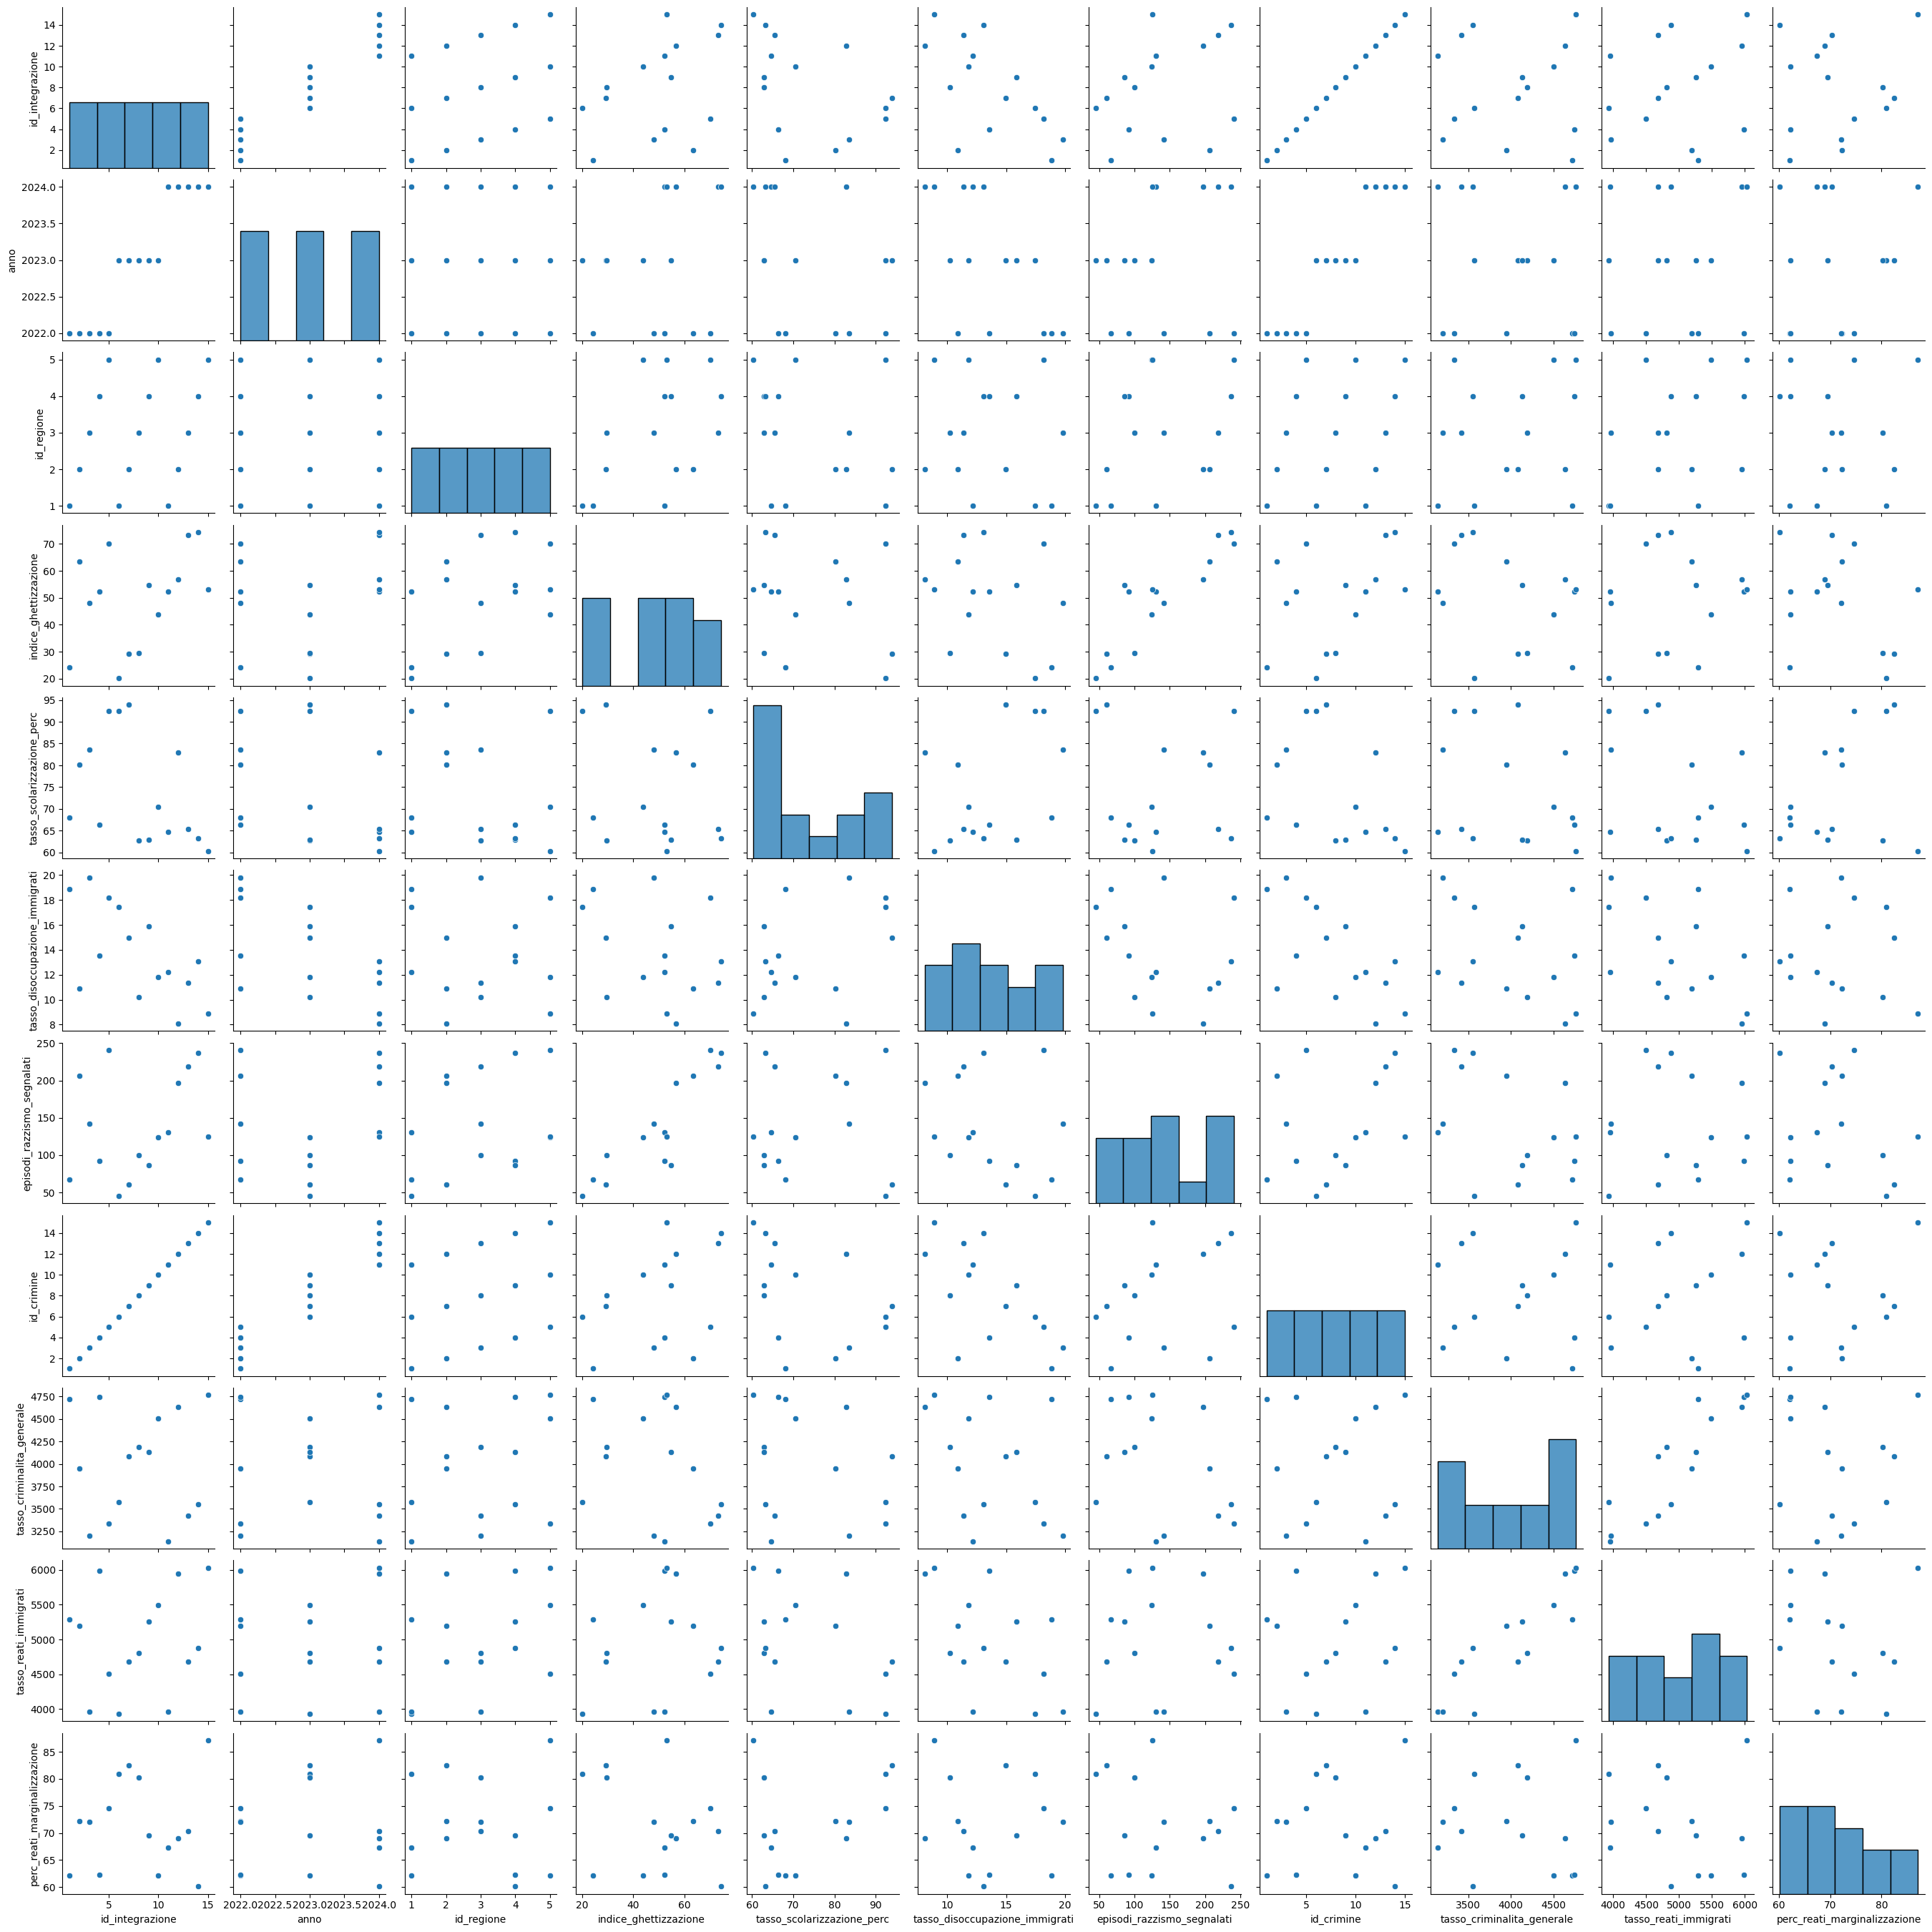

In [ ]:
##distribuzione di ogni singola variabile presente nel dataframe
import seaborn as sns
import matplotlib.pyplot as plt

USER = 'root'
PASSWORD = '25DATITA034!'
HOST = '5.tcp.eu.ngrok.io'
PORT = 14158
DATABASE = 'immigrazione_3nf'

dataframe = read_view_studio_razzismo()
#tramite la funzione pairplot della libreria seaborn visualizzo la distribuzione di ogni singola variabile presente nel dataset, rispetto a tutte le altre
sns.pairplot(dataframe)

Successivamente, ci siamo concentrati sulla parte della base dati contenente dati e indici relativi alla discriminazione degli stranieri immigrati in Italia. Nello specifico, abbiamo utilizzato un indice di ghettizzazione che è un dato che comprende varie misurazioni tra cui disoccupazione, scolarizzazione e episodi di razzismo segnalati. Per studiare come questi indici si correlano tra loro abbiamo creato un grafico a mappa di calore: questa tabella mostra in maniera visiva il coefficiente di correlazione tra due variabili secondo un gradiente di colore. Più il coefficiente si avvicina a 1 e più la correlazione è direttamente proporzionale e il colore tende al rosso, mentre più si avvicina a -1 e più la correlazione è inversamente proporzionale e il colore tenderà al blu.

/tmp/ipykernel_8667/2033802852.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  DF=pd.read_sql(query,conn)


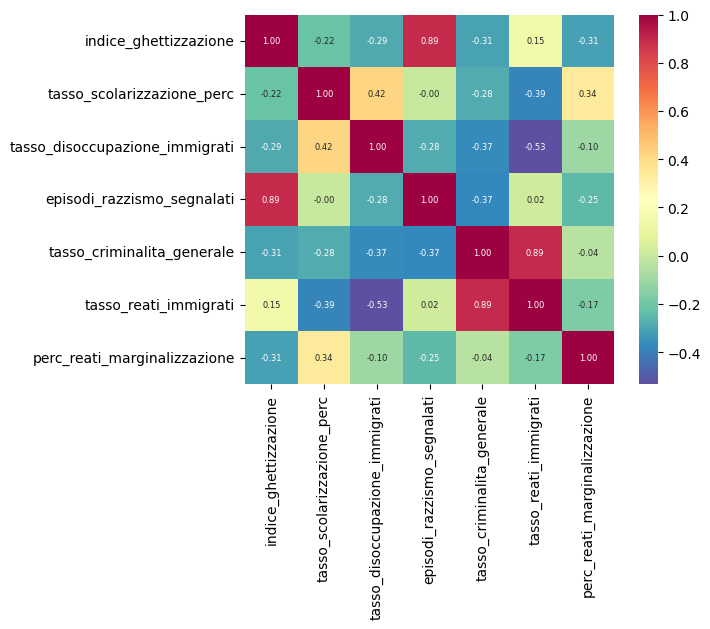

In [ ]:
#heatmap della view_studio_razzismo
import seaborn as sns
import matplotlib.pyplot as plt
dataframe = read_view_studio_razzismo()
columns_to_drop = ['anno', 'id_regione', 'id_integrazione', 'id_crimine']
dataframe_filtered = dataframe.drop(columns=columns_to_drop, errors='ignore')
corrmat = dataframe_filtered.select_dtypes(include=['number']).corr()
hm = sns.heatmap(corrmat, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 6}, yticklabels=corrmat.columns, xticklabels=corrmat.columns, cmap="Spectral_r")
plt.show()

Solitamente in statistica si preferisce considerare le correlazioni con un coefficiente di valore assoluto intorno allo 0.6. Per questo motivo le correlazioni che potremmo prendere in considerazione sono due: episodi di razzismo segnalati contro indice di ghettizzazione e tasso reati immigrati contro tasso criminalità generale. Tuttavia questo coefficiente di correlazione molto alto (0,89) è dovuto al fatto che gli episodi di razzismo segnalati sono una delle misure che compone l'indice di ghettizzazione, quindi è normale che la correlazione sia alta; anche per i tassi di reati vale lo stesso discorso.
L'unica correlazione che abbiamo ritenuto importante da approfondire è quella inversamente proporzionale tra tasso di scolarizzazione percentuale e il tasso reati immigrati, che ha un coefficiente negativo di -0,39.

In [ ]:
# @title
USER = 'root'
PASSWORD = '25DATITA034!'
HOST = '7.tcp.eu.ngrok.io'
PORT = 11139
DATABASE = 'immigrazione_3nf_reale'

In [ ]:
# @title
#procedura per stabilire una connessione con il database
def stabilisciConnessioneData():
  conn = mysql.connector.connect(
  user=USER,
  password=PASSWORD,
  host=HOST,
  port=PORT,
  database=DATABASE
)
  return conn

In [ ]:
# @title
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Database connection parameters for 'immigrazione_3nf_reale'
USER = 'root'
PASSWORD = '25DATITA034!'
HOST = '5.tcp.eu.ngrok.io'
PORT = 14158
DATABASE = 'immigrazione_3nf'

def stabilisciConnessioneData():
  conn = mysql.connector.connect(
  user=USER,
  password=PASSWORD,
  host=HOST,
  port=PORT,
  database=DATABASE
)
  return conn

/tmp/ipykernel_8667/1485617516.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM immigrazione_3nf.view_studio_totale_razzismo", conn)


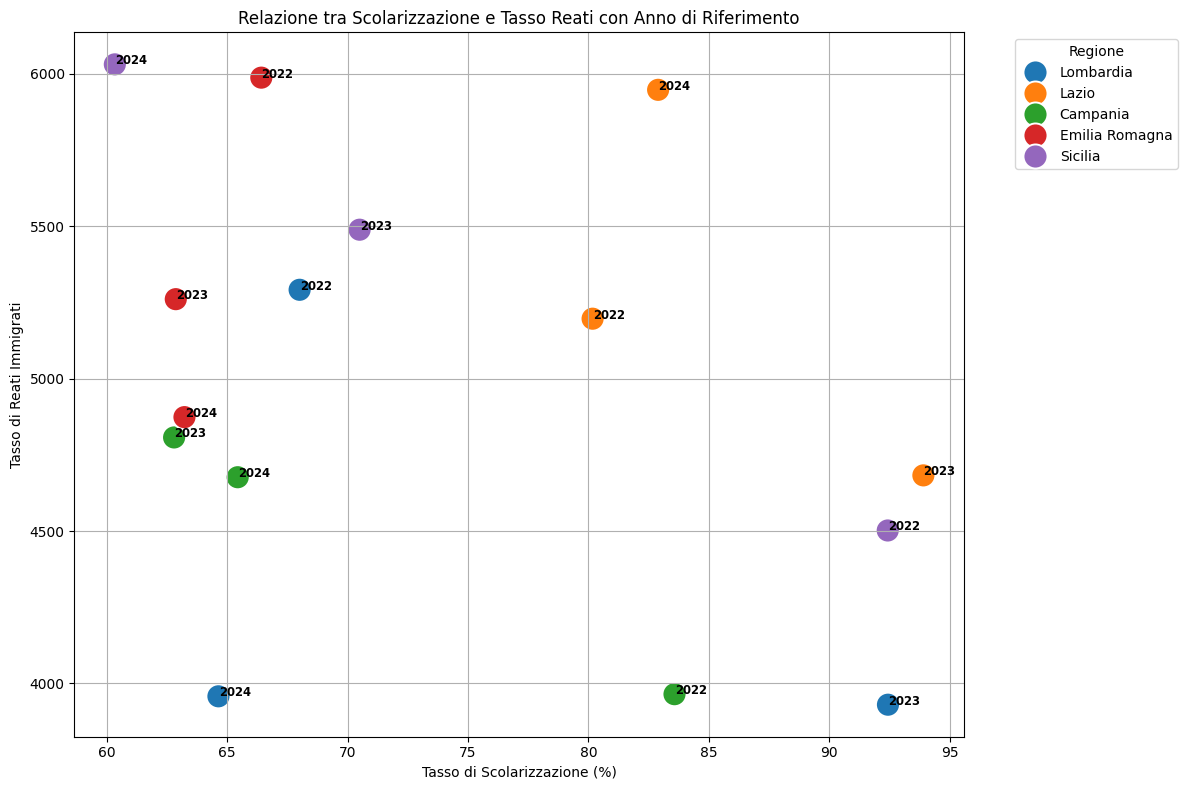

In [ ]:
# Caricamento dati (dalla VIEW o query SQL)
conn = stabilisciConnessioneData() # Establish a new connection
df = pd.read_sql("SELECT * FROM immigrazione_3nf.view_studio_totale_razzismo", conn)
conn.close() # Close the connection after use

# Grafico di dispersione
plt.figure(figsize=(12, 8)) # Increased figure size for better label visibility
sns.scatterplot(data=df, x='tasso_scolarizzazione_perc', y='tasso_reati_immigrati', hue='nome_regione', s=300) # Increased point size to 100

# Add 'anno' (year) labels to each point
for line in range(0, df.shape[0]):
     plt.text(df.iloc[line]['tasso_scolarizzazione_perc'] + 0.01,
              df.iloc[line]['tasso_reati_immigrati'],
              df.iloc[line]['anno'],
              horizontalalignment='left',
              size='small',
              color='black',
              weight='semibold')

plt.title('Relazione tra Scolarizzazione e Tasso Reati con Anno di Riferimento')
plt.xlabel('Tasso di Scolarizzazione (%)')
plt.ylabel('Tasso di Reati Immigrati')
plt.legend(title='Regione', bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In questo grafico a dispersione analizziamo la relazione tra scolarizzazione e tasso reati per le regioni italiane più significative per questo studio, per il triennio 2022-2024.
Da questo grafico possiamo notare che, salvo alcuni outlier, la maggior parte delle regioni in cui viene registrato un minor tasso di scolarizzazione presentano un tasso reati più alto rispetto alle regioni con alto tasso di scolarizzazione.

In [ ]:
def read_view_studio_razzismo():
  conn=stabilisciConnessioneData()
  mycursor = conn.cursor()
  query = "SELECT * FROM immigrazione_3nf.view_studio_razzismo"
  DF=pd.read_sql(query,conn)
  conn.close()
  return DF

In [ ]:
def read_VW_ImmigrazioneStatistiche() :
  conn=stabilisciConnessioneData()
  mycursor = conn.cursor()
  query = "SELECT * FROM immigrazione_3nf.vw_immigrazionestatistiche"
  DF_stat=pd.read_sql(query,conn)
  conn.close()
  return DF_stat

Ci spostiamo su una visualizzazione di dati dove abbiamo raggruppato i dataset statistici e anche qui siamo partiti con un pairplot per vedere a grandi linee le correlazioni.

/tmp/ipykernel_8667/1328995555.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  DF_stat=pd.read_sql(query,conn)


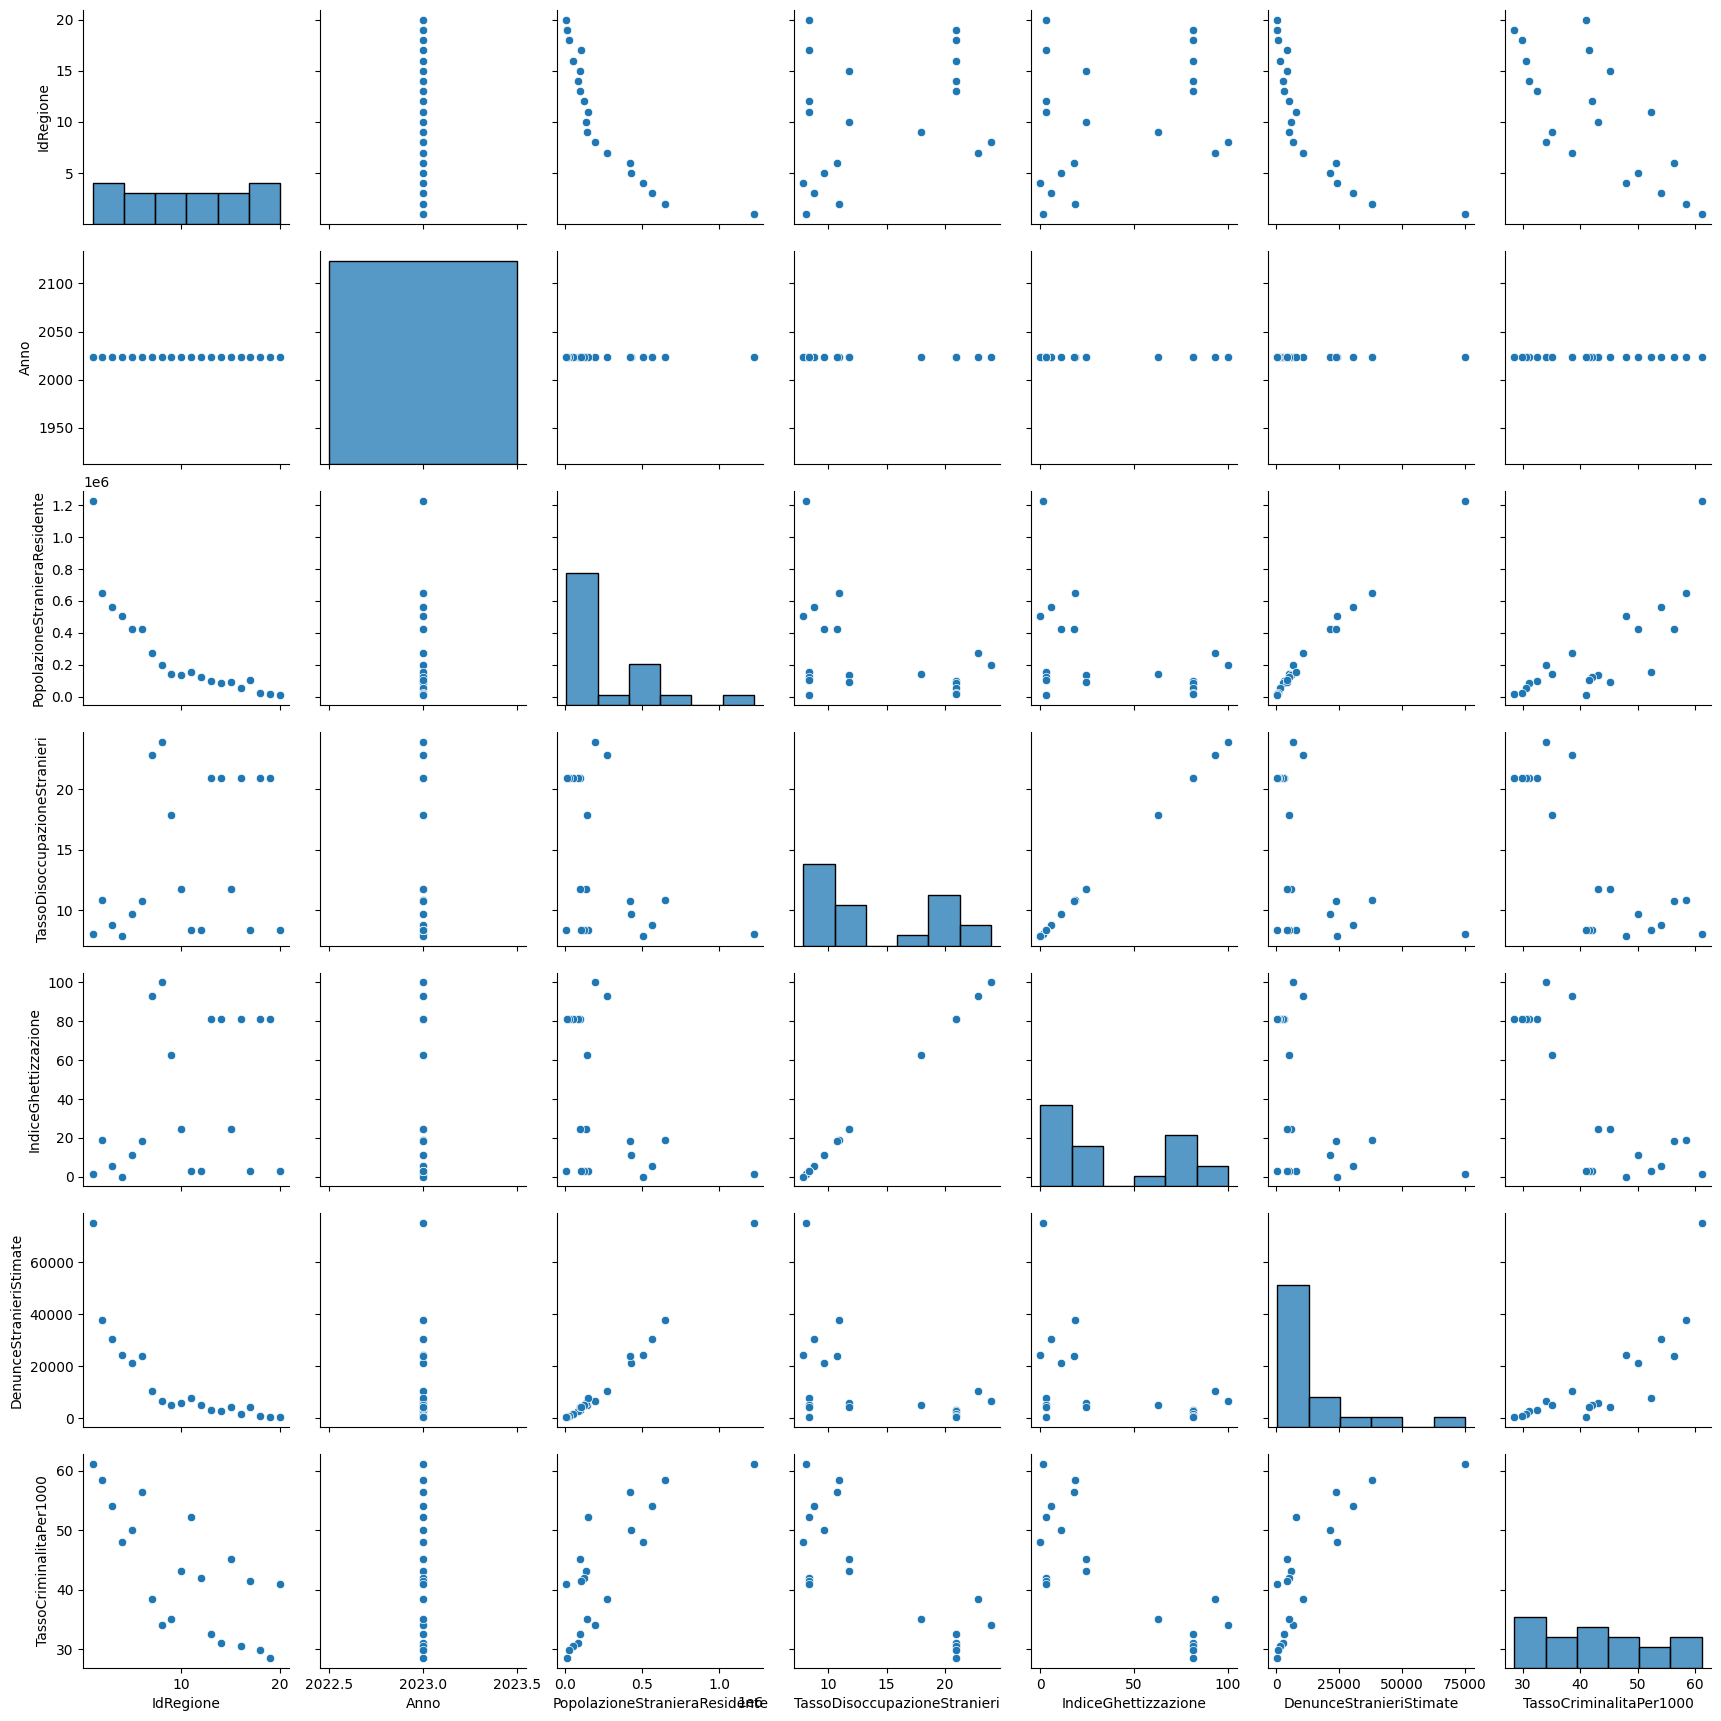

In [ ]:
##distribuzione di ogni singola variabile presente nel dataframe
import seaborn as sns
import matplotlib.pyplot as plt

dataframe = read_VW_ImmigrazioneStatistiche()
#tramite la funzione pairplot della libreria seaborn visualizzo la distribuzione di ogni singola variabile presente nel dataset, rispetto a tutte le altre
sns.pairplot(dataframe)

/tmp/ipykernel_8667/1204637542.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  DF_stat=pd.read_sql(query,conn)


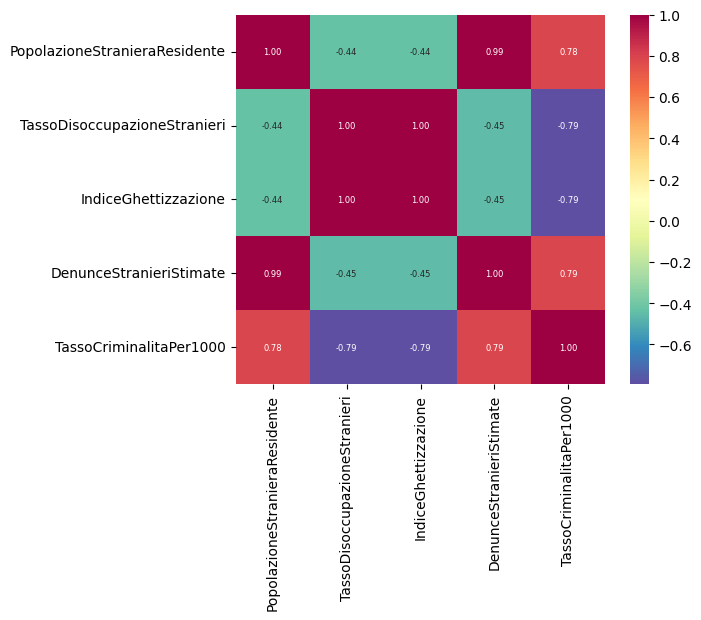

In [ ]:
USER = 'root'
PASSWORD = '25DATITA034!'
HOST = '5.tcp.eu.ngrok.io'
PORT = 14158
DATABASE = 'immigrazione_3nf'

def stabilisciConnessioneData():
  conn = mysql.connector.connect(
  user=USER,
  password=PASSWORD,
  host=HOST,
  port=PORT,
  database=DATABASE
)
  return conn

def read_VW_ImmigrazioneStatistiche() :
  conn=stabilisciConnessioneData()
  mycursor = conn.cursor()
  query = "SELECT * FROM immigrazione_3nf.vw_immigrazionestatistiche"
  DF_stat=pd.read_sql(query,conn)
  conn.close()
  return DF_stat

#generazione di heatmap sulla view studio_integrazione_criminalità
dataframe = read_VW_ImmigrazioneStatistiche()
columns_to_drop = ['Anno', 'IdRegione']
dataframe_filtered = dataframe.drop(columns=columns_to_drop, errors='ignore')
corrmat = dataframe_filtered.select_dtypes(include=['number']).corr()

hm = sns.heatmap(corrmat, cbar=True, annot=True, square = True, fmt = '.2f', annot_kws={'size':6}, yticklabels=corrmat.columns, xticklabels=corrmat.columns, cmap="Spectral_r")
plt.show()

Successivamente abbiamo approfondito lo studio delle correlazioni con un'altra mappa di calore. A differenza della precedente, questa mappa ci presenta delle correlazioni interessanti:

*   con un coefficiente negativo di -0,79 abbiamo la correlazione inversamente proporzionale tra tasso di disoccupazione e tasso di criminalità

*   con un coefficiente di 1 abbiamo la correlazione direttamente proporzionale tra l'indice di ghettizzazione e il tasso di disoccupazione stranieri

Entrambe queste correlazioni meritano un approfondimento in grafici a parte

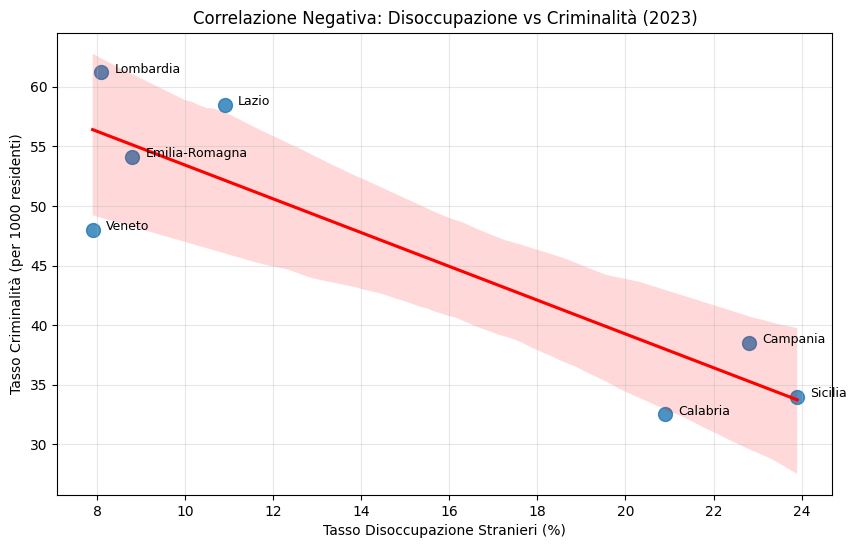

In [ ]:
# @title
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dati estratti da FACT_ImmigrazioneStatistiche
data = {
    'Regione': ['Lombardia', 'Lazio', 'Emilia-Romagna', 'Veneto', 'Campania', 'Sicilia', 'Calabria'],
    'Disoccupazione': [8.1, 10.9, 8.8, 7.9, 22.8, 23.9, 20.9],
    'TassoCriminalita': [61.2, 58.5, 54.1, 48.0, 38.5, 34.0, 32.5]
}
df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.regplot(x='Disoccupazione', y='TassoCriminalita', data=df, scatter_kws={'s':100}, line_kws={'color':'red'})

# Etichette per le regioni
for i in range(df.shape[0]):
    plt.text(df.Disoccupazione[i]+0.3, df.TassoCriminalita[i], df.Regione[i], fontsize=9)

plt.title('Correlazione Negativa: Disoccupazione vs Criminalità (2023)')
plt.xlabel('Tasso Disoccupazione Stranieri (%)')
plt.ylabel('Tasso Criminalità (per 1000 residenti)')
plt.grid(alpha=0.3)
plt.show()

Questo grafico a dispersione serve a visualizzare visivamente la sopracitata correlazione negativa di -0.79 tra tasso di disoccupazione e tasso di criminalità.
La linea rossa rappresenta la media tendenziale mentre l'area attorno è il range medio entro il quale ci sono la maggior parte dei valori. I valori all'esterno dell'area sono outlier.
Dimostra che all'aumentare della disoccupazione straniera, il tasso di criminalità paradossalmente diminuisce. Sembra controintuitivo ma approfondendo l'analisi abbiamo scoperto che
in realtà, i reati predatori (furti, scippi) avvengono dove circola più ricchezza.


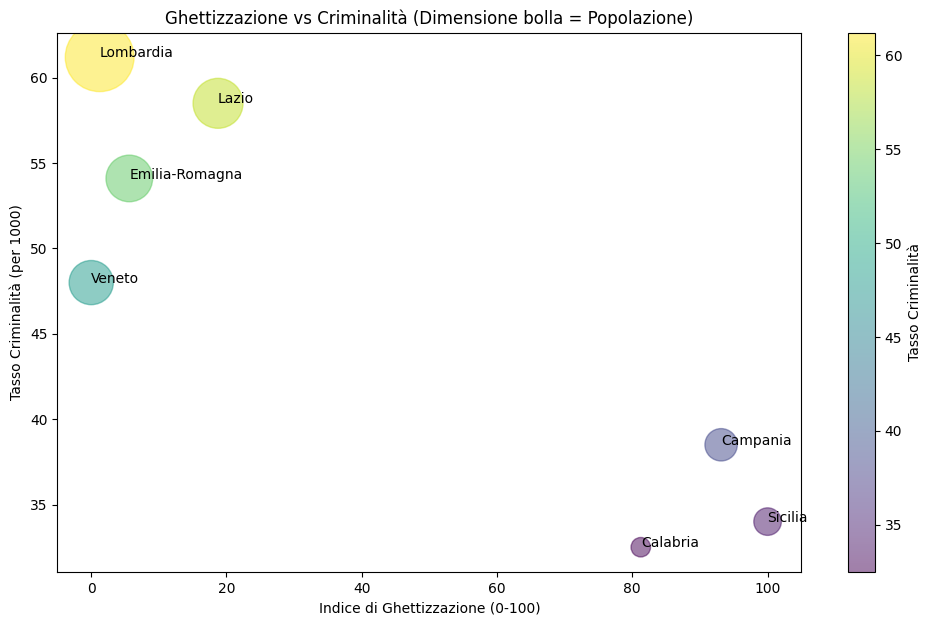

In [ ]:
# Aggiungiamo i dati di popolazione e ghettizzazione
df['Ghettizzazione'] = [1.25, 18.75, 5.63, 0.0, 93.13, 100.0, 81.25]
df['Popolazione'] = [1225500, 647200, 563800, 506200, 271800, 196500, 98100]

plt.figure(figsize=(12, 7))
bubble = plt.scatter(df.Ghettizzazione, df.TassoCriminalita, s=df.Popolazione/500,
                     alpha=0.5, c=df.TassoCriminalita, cmap='viridis')

plt.colorbar(bubble, label='Tasso Criminalità')
plt.title('Ghettizzazione vs Criminalità (Dimensione bolla = Popolazione)')
plt.xlabel('Indice di Ghettizzazione (0-100)')
plt.ylabel('Tasso Criminalità (per 1000)')

for i, txt in enumerate(df.Regione):
    plt.annotate(txt, (df.Ghettizzazione[i], df.TassoCriminalita[i]), fontsize=10)

plt.show()

Questo grafico a dispersione mette in relazione l'Indice di Ghettizzazione con il Tasso di Criminalità, usando la dimensione della bolla per rappresentare la Popolazione Straniera Residente.
Da qui abbiamo notato due gruppi distinti: il "Cluster Sud" (bolle piccole, alta ghettizzazione, bassa criminalità) e il "Cluster Nord" (bolle grandi, bassa ghettizzazione, alta criminalità).

/tmp/ipykernel_8667/234316573.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regione', y='TassoCriminalita', data=df_sorted, ax=ax1, palette='Blues_r')


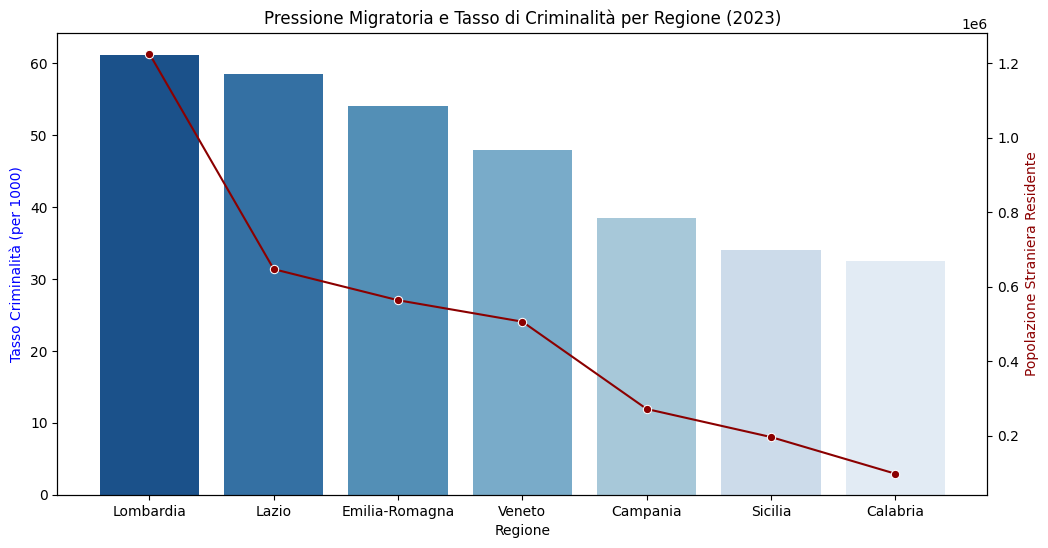

In [ ]:
# Ordinamento per tasso di criminalità decrescente
df_sorted = df.sort_values('TassoCriminalita', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Primo asse: Tasso per 1000
sns.barplot(x='Regione', y='TassoCriminalita', data=df_sorted, ax=ax1, palette='Blues_r')
ax1.set_ylabel('Tasso Criminalità (per 1000)', color='blue')

# Secondo asse: Popolazione totale
ax2 = ax1.twinx()
sns.lineplot(x='Regione', y='Popolazione', data=df_sorted, ax=ax2, color='darkred', marker='o')
ax2.set_ylabel('Popolazione Straniera Residente', color='darkred')

plt.title('Pressione Migratoria e Tasso di Criminalità per Regione (2023)')
plt.xticks(rotation=45)
plt.show()

Abbiamo deciso di approfondire anche la correlazione tra tasso di criminalità, con un grafico a barre comparato, e popolazione straniera residente con un grafico a linea.
Questo risulta in un confronto diretto tra le denunce totali stimate e il tasso per 1000 abitanti per regione.
Abbiamo capito che le Regioni come la Lombardia gestiscono una massa critica enorme (75.000 denunce stimate) con una popolazione straniera di oltre 1,2 milioni, mantenendo però il tasso di criminalità più alto d'Italia (61.2).